# Matplotlib

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.

## Plan of this lecture

#### Scatter plot

California housing dataset.

#### Line plot

Flight dataset.

#### Histogram

FIFA dataset.

#### Goal of the lecture

1. Understand three methods/plots.

2. Data processing/manipulation is important since we cannot guarantee that we have the perfect data.

3. Data analysis and conclusions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pip install -U scikit-learn

# Scatter Plot

## Case Study: California housing dataset

In [2]:
# read dataset from sklearn
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

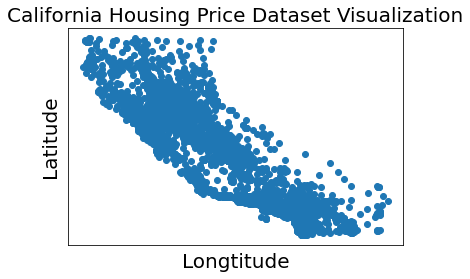

In [12]:
# take features
X = housing.data
features = housing.feature_names

# target
median_house_value = housing.target

# Latitude and Longitude
latitude = X[:,-2]
longitude = X[:,-1]

# visualization
plt.scatter(longitude, latitude)
plt.xlabel('Longtitude', size=20)
plt.ylabel('Latitude',size=20)
plt.xticks([])
plt.yticks([])
plt.title('California Housing Price Dataset Visualization', size=20)
plt.savefig('CHP.jpg')

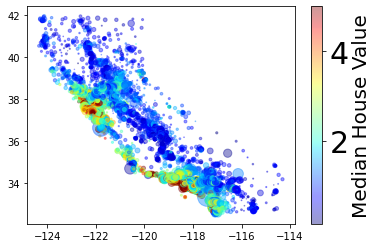

In [23]:
# Version 2:

population = X[:,4]

# visualization
plt.scatter(longitude, latitude, alpha=0.4, s=population/100, c=median_house_value, cmap=plt.get_cmap('jet'))
cbar = plt.colorbar(orientation='vertical')
# label fontsize
cbar.set_label(label='Median House Value', size=20)
# values fontsize
cbar.ax.tick_params(labelsize=30)
plt.show()

In [15]:
# Conclusion:
# 1. I observe two regions with high median house values, they are LA and Bay area. 
# 2. The population rate is high in the west LA and south LA. 

array([ 322., 2401.,  496., ..., 1007.,  741., 1387.])

# Line Plot

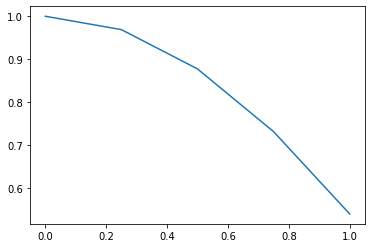

In [24]:
# Line plot connects the point I provide. 

# When I use line plot, x coordinates are order. 
# This is why I use np.linspace, not np.random.uniform
x = np.linspace(0,1,5)
y = np.cos(x)
plt.plot(x,y)

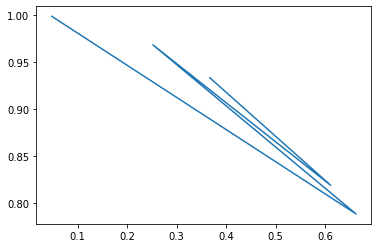

In [26]:
# bad example
x = np.random.uniform(0,1,size=(5,))
y = np.cos(x)

plt.plot(x,y)

## Case study: Flight dataset

In [2]:
url = 'https://raw.githubusercontent.com/liaochunyang/PIC16/refs/heads/main/PIC16A/data/flights.csv'
df = pd.read_csv(url)
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


#### Example 1: Visualize the monthly number of passengers for each year.

['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
12
[1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960]


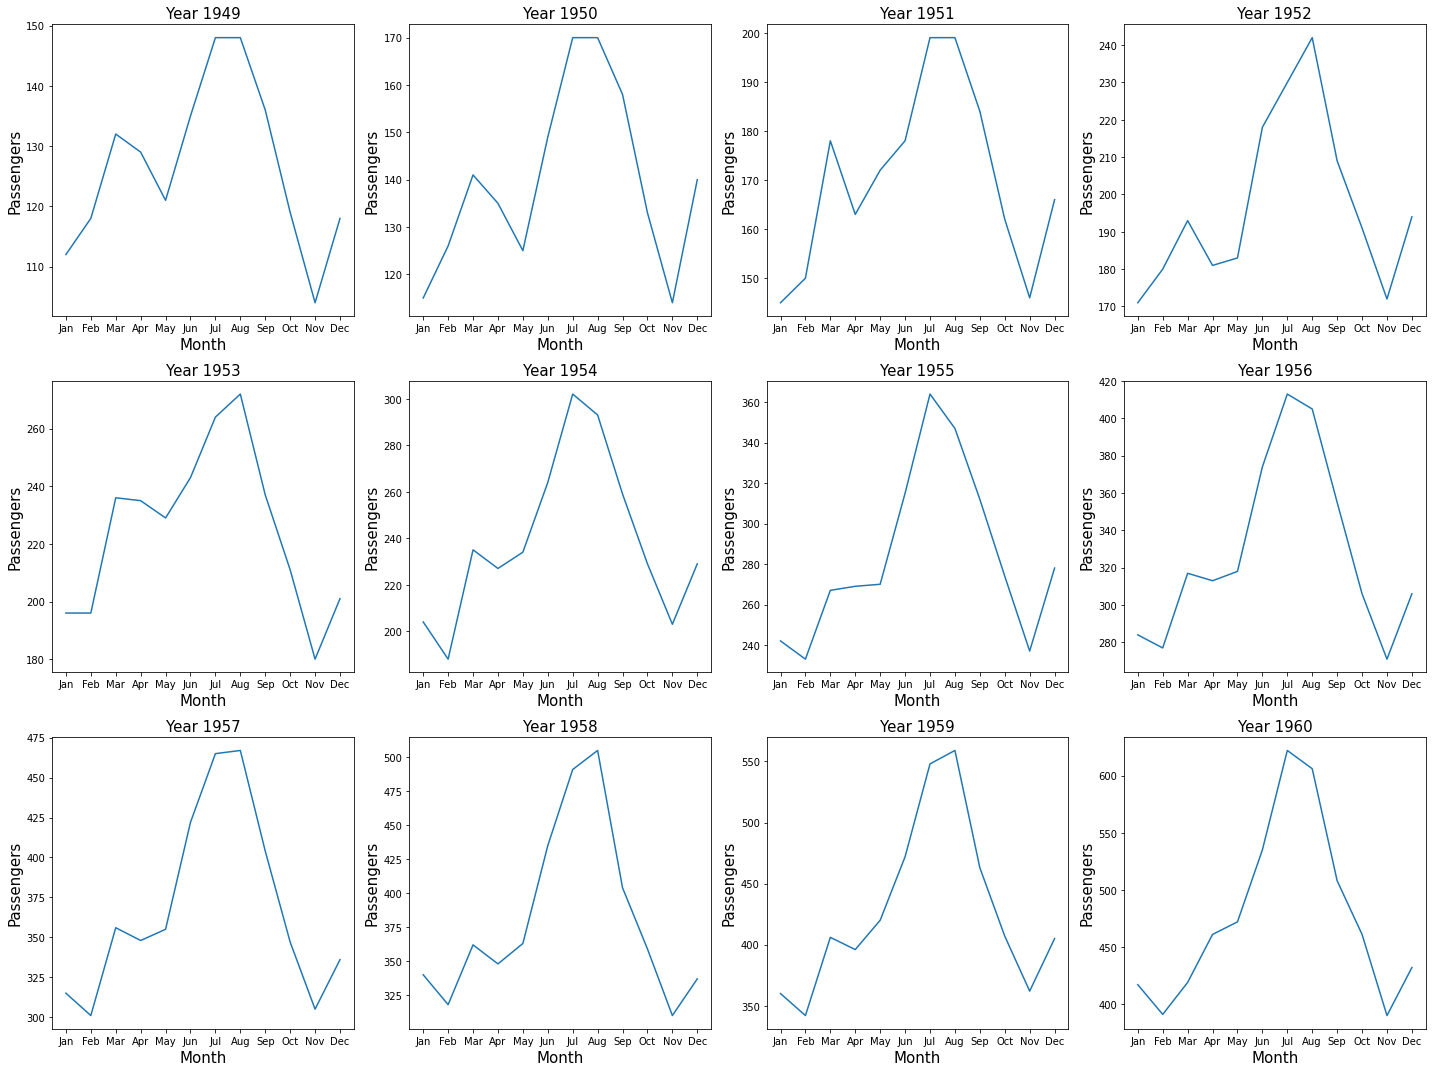

In [6]:
# pre-process month
month = list( df['month'].unique() )
print(month)
month_int = range(1,13)

# pre-process year
length_of_year = len( df['year'].unique() )
print(length_of_year)
print(df['year'].unique())

# I am using subplots
fig, ax = plt.subplots(3,4,figsize=(20,15))

for i in range(length_of_year):
    
    # looking for a certain year
    year = df['year'].unique()[i]
    
    # get x and y values
    x = df[ df['year'] == year ]['month']
    y = df[ df['year'] == year ]['passengers']
    
    # determine index 
    row = i // 4      # 4 is the number of columns in the subplots.
    col = i % 4
    
    # visualization
    ax[row, col].plot(x,y)
    # set title
    ax[row, col].set_title(f'Year {year}', size=15)
    # set x-label and y-label
    ax[row, col].set_xlabel('Month', size=15)
    ax[row, col].set_ylabel('Passengers', size=15)
    
# set up a better layout
plt.tight_layout()

row and column index 

a = b * a//b + a%b
a//b: quotient
a%b: remainder

['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
12
[1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960]


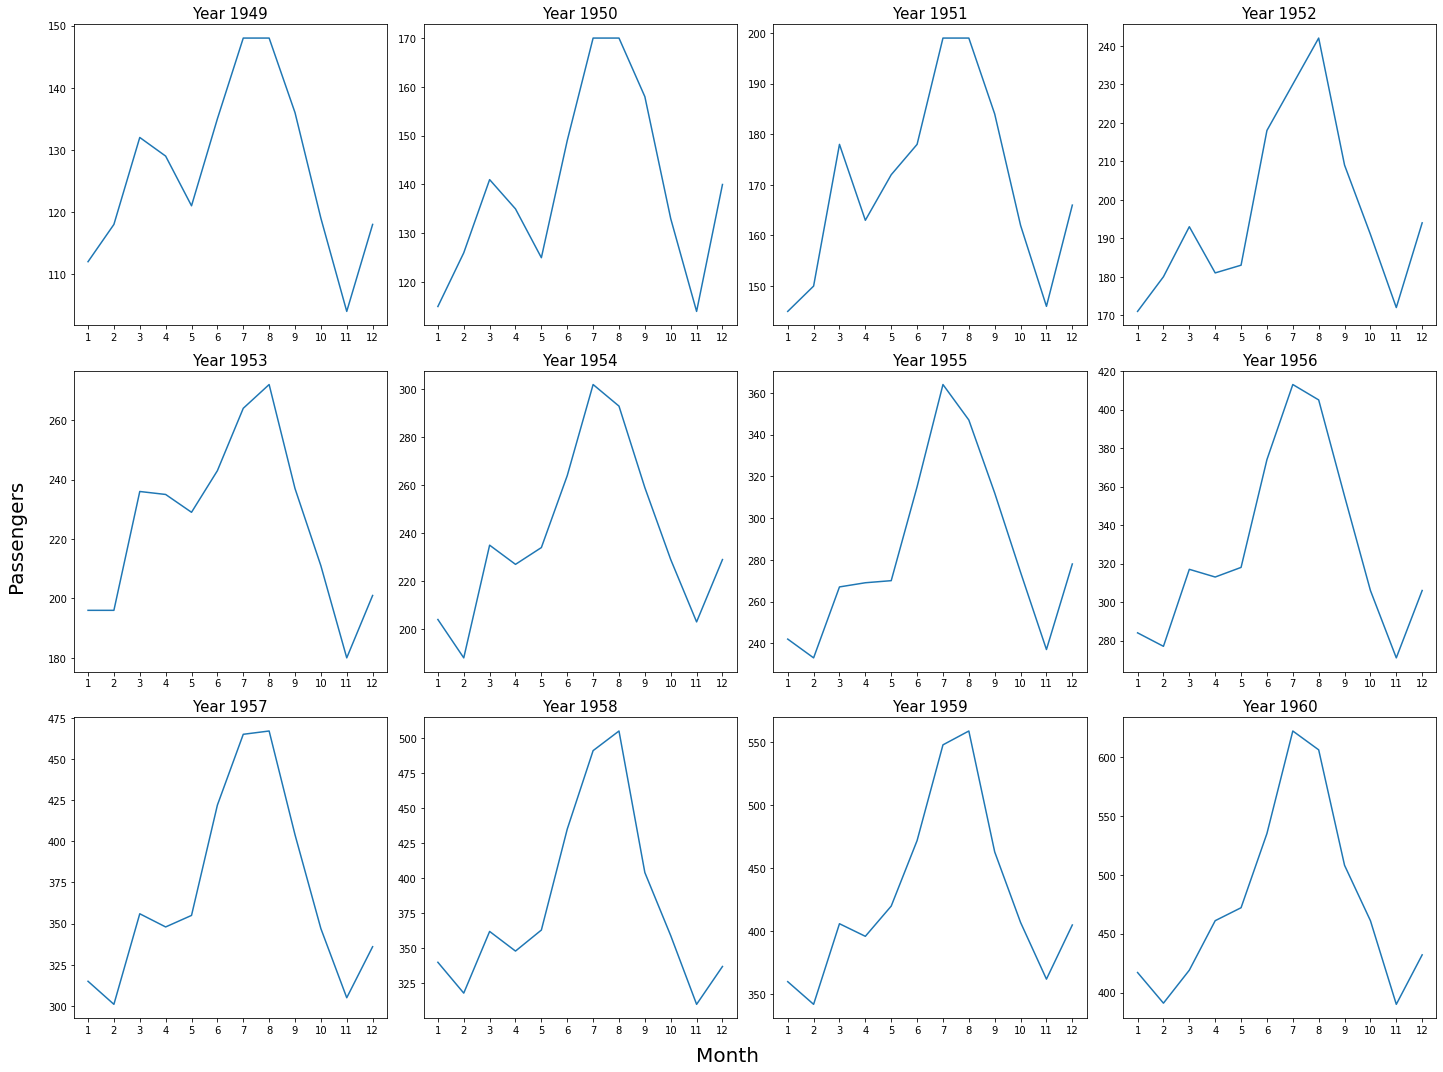

In [11]:
# Version 2: use numbers as xticks
# Version 3: I have global xlabels and ylabels instead of using x and y labels for each subfigure.

# pre-process month
month = list( df['month'].unique() )
print(month)
month_int = range(1,13)

# pre-process year
length_of_year = len( df['year'].unique() )
print(length_of_year)
print(df['year'].unique())

# I am using subplots
fig, ax = plt.subplots(3,4,figsize=(20,15))

for i in range(length_of_year):
    
    # looking for a certain year
    year = df['year'].unique()[i]
    
    # get x and y values
    x = df[ df['year'] == year ]['month']
    y = df[ df['year'] == year ]['passengers']
    
    # determine index 
    row = i // 4      # 4 is the number of columns in the subplots.
    col = i % 4
    
    # visualization
    ax[row, col].plot(x,y)
    # set title
    ax[row, col].set_title(f'Year {year}', size=15)
    # set x-label and y-label
    #ax[row, col].set_xlabel('Month', size=15)
    #ax[row, col].set_ylabel('Passengers', size=15)
    # set xticks
    ax[row, col].set_xticks(month, month_int, size=10)    # first position: original ticks # second position: new ticks

    
# suplevel x and y labels:
fig.supxlabel('Month', size=20)
fig.supylabel('Passengers', size=20, x=0)  # keyword x allows me to change the x position, i.e change font position horizontally.
                                           # keyword y changes y position.
# set up a better layout
plt.tight_layout()

# Histogram

Histogram shows the distribution of numeric data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

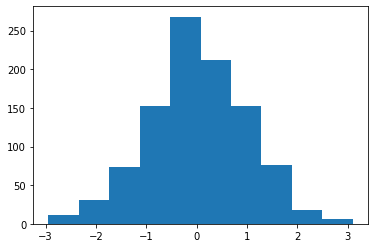

In [8]:
# normal distribution
m = 1000
x_normal = np.random.normal(0,1,size=(m,))  # random numbers of shape (m,) from normal distribution with mean=0, std=1.

# histogram
plt.hist(x_normal)
plt.show()

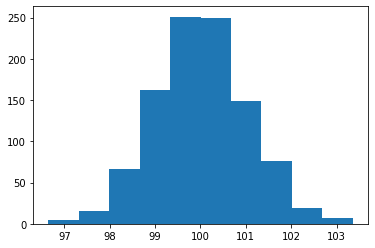

In [9]:
# normal distribution
m = 1000
x_normal = np.random.normal(100,1,size=(m,))  # random numbers of shape (m,) from normal distribution with mean=100, std=1.

# histogram
plt.hist(x_normal)
plt.show()

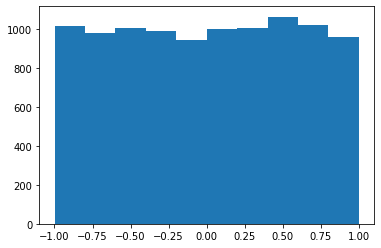

In [12]:
# Uniform distribution
m = 10000
# generate random numbers (shape=(m,)) following uniform distribution in the interval [-1,1]
x_unif = np.random.uniform(-1,1,size=(m,))
# histogram
plt.hist(x_unif)
plt.show()

# Application: Visualize fifa goal data


#### Background:

**Exponential distribution** is used to describe the time between two events.

#### Task:

Verify exponential distribution using real data, i.e. fifa goal data. 

In [14]:
# read csv file
df = pd.read_csv('fifa.csv', encoding="Windows-1252")
df

,key_id,goal_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,...,shirt_number,player_team_id,player_team_name,player_team_code,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty
0,1,G-0001,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,19',19,0,first half,0,0
1,2,G-0002,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,40',40,0,first half,0,0
2,3,G-0003,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,43',43,0,first half,0,0
3,4,G-0004,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-44,...,0,T-44,Mexico,MEX,70',70,0,second half,0,0
4,5,G-0005,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,87',87,0,second half,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,2716,G-2716,WC-2022,2022 FIFA World Cup,M-2022-64,Argentina v France,12/18/2022,final,not applicable,T-03,...,11,T-03,Argentina,ARG,36',36,0,first half,0,0
2716,2717,G-2717,WC-2022,2022 FIFA World Cup,M-2022-64,Argentina v France,12/18/2022,final,not applicable,T-28,...,10,T-28,France,FRA,80',80,0,second half,0,1
2717,2718,G-2718,WC-2022,2022 FIFA World Cup,M-2022-64,Argentina v France,12/18/2022,final,not applicable,T-28,...,10,T-28,France,FRA,81',81,0,second half,0,0
2718,2719,G-2719,WC-2022,2022 FIFA World Cup,M-2022-64,Argentina v France,12/18/2022,final,not applicable,T-03,...,10,T-03,Argentina,ARG,108',108,0,"extra time, second half",0,0


In [15]:
df.head(10)

,key_id,goal_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,...,shirt_number,player_team_id,player_team_name,player_team_code,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty
0,1,G-0001,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,19',19,0,first half,0,0
1,2,G-0002,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,40',40,0,first half,0,0
2,3,G-0003,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,43',43,0,first half,0,0
3,4,G-0004,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-44,...,0,T-44,Mexico,MEX,70',70,0,second half,0,0
4,5,G-0005,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,7/13/1930,group stage,Group 1,T-28,...,0,T-28,France,FRA,87',87,0,second half,0,0
5,6,G-0006,WC-1930,1930 FIFA World Cup,M-1930-02,United States v Belgium,7/13/1930,group stage,Group 4,T-80,...,0,T-80,United States,USA,23',23,0,first half,0,0
6,7,G-0007,WC-1930,1930 FIFA World Cup,M-1930-02,United States v Belgium,7/13/1930,group stage,Group 4,T-80,...,0,T-80,United States,USA,45',45,0,first half,0,0
7,8,G-0008,WC-1930,1930 FIFA World Cup,M-1930-02,United States v Belgium,7/13/1930,group stage,Group 4,T-80,...,0,T-80,United States,USA,69',69,0,second half,0,0
8,9,G-0009,WC-1930,1930 FIFA World Cup,M-1930-03,Yugoslavia v Brazil,7/14/1930,group stage,Group 2,T-84,...,0,T-84,Yugoslavia,YUG,21',21,0,first half,0,0
9,10,G-0010,WC-1930,1930 FIFA World Cup,M-1930-03,Yugoslavia v Brazil,7/14/1930,group stage,Group 2,T-84,...,0,T-84,Yugoslavia,YUG,30',30,0,first half,0,0


In [24]:
# I want to take minute_regulation column.
time = df['minute_regulation']
time = time.to_numpy()
print(time)

# compute the difference of two consecutive numbers
duration = np.diff(time)
print(duration[:10])

# data preprocessing: Compute time between two goals of different games
mask = (duration < 0)   # check events cross different games
duration[mask] = duration[mask] + 90   # modify the duration by adding 90
print(duration[:10])

# Is it enough? It is possible to have extra time/ overtime in round of 16, quarterfinal, semifinal, final.
print(np.min(duration))
print(np.argmin(duration))

# data processing:
mask = (duration < 0)   # check events with overtime
duration[mask] = duration[mask] + 30   # modify the duration by adding 30

[ 19  40  43 ...  81 108 118]
[ 21   3  27  17 -64  22  24 -48   9  32]
[21  3 27 17 26 22 24 42  9 32]
-21
1716


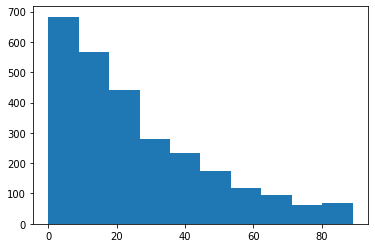

(array([1493.,  647.,  330.,  134.,   54.,   35.,   14.,    5.,    5.,
           2.]),
 array([3.52096076e-02, 2.01606537e+01, 4.02860977e+01, 6.04115418e+01,
        8.05369858e+01, 1.00662430e+02, 1.20787874e+02, 1.40913318e+02,
        1.61038762e+02, 1.81164206e+02, 2.01289650e+02]),
 <BarContainer object of 10 artists>)

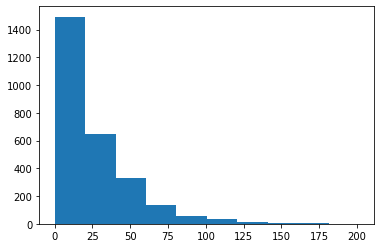

In [28]:
# visualize duration
plt.hist(duration)
plt.show()


# visualize exponential distribution by generating some random numbers
m = np.size(duration)
# sample mean
scale = np.mean(duration)
x = np.random.exponential(scale=scale, size=(m,))
# visualize random numbers
plt.hist(x)

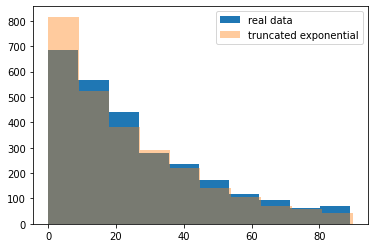

In [31]:
# visualize duration
plt.hist(duration, label='real data')

# visualize exponential distribution by generating some random numbers
m = np.size(duration)
# sample mean
scale = np.mean(duration)
x = np.random.exponential(scale=scale, size=(m,))

# should do truncation
mask = (x<90)
x = x[mask]

# visualize random numbers
plt.hist(x, alpha=0.4, label='truncated exponential')
plt.legend()

## Good! Conclusion: time between two goals follows exponential distribution.
## assumption: I do not consider the goals in the injury time. If the goals happend in the injury time,
## the goal time would be 90 minutes. 